# Notebook 5: SHAP Analysis for Model Interpretability
- Global feature importance with SHAP
- Individual transaction explanations
- Understanding model decisions

## Setup & Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

# Style settings
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "#0F1117"})

SEED = 42
np.random.seed(SEED)

## Load data and model

In [3]:
import joblib
df = pd.read_csv("data/data_feature_engineered.csv")
FEATURES = np.load("data/features_list.npy", allow_pickle=True).tolist()
xgb_model = joblib.load("models/xgboost_model.pkl")
X = df[FEATURES].values
y = df["Is_Fraud"].values

print("Data and model loaded")

Data and model loaded


## Prepare SHAP Data

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Sample for faster SHAP computation
shap_sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_shap = X_test[shap_sample_idx]

print(f"SHAP sample size: {len(X_shap)} transactions")
print("Computing SHAP values (may take 30-60 seconds)...")

SHAP sample size: 2000 transactions
Computing SHAP values (may take 30-60 seconds)...


## Calculate SHAP Values

In [5]:
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_shap)

print("SHAP values computed")

SHAP values computed


## SHAP Beeswarm Plot

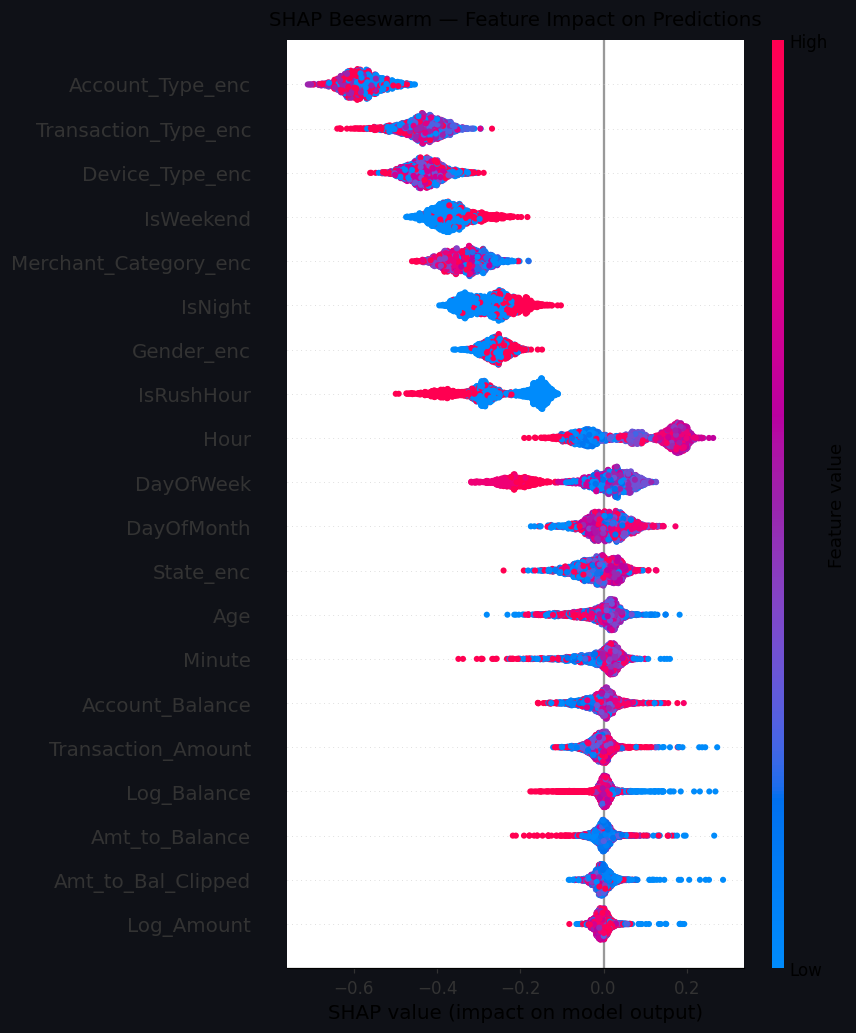

In [7]:
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=FEATURES,
    plot_type="dot",
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact on Predictions", fontsize=13, pad=10)
plt.tight_layout()
plt.show()

## SHAP Bar Plot (Mean Absolute Impact)

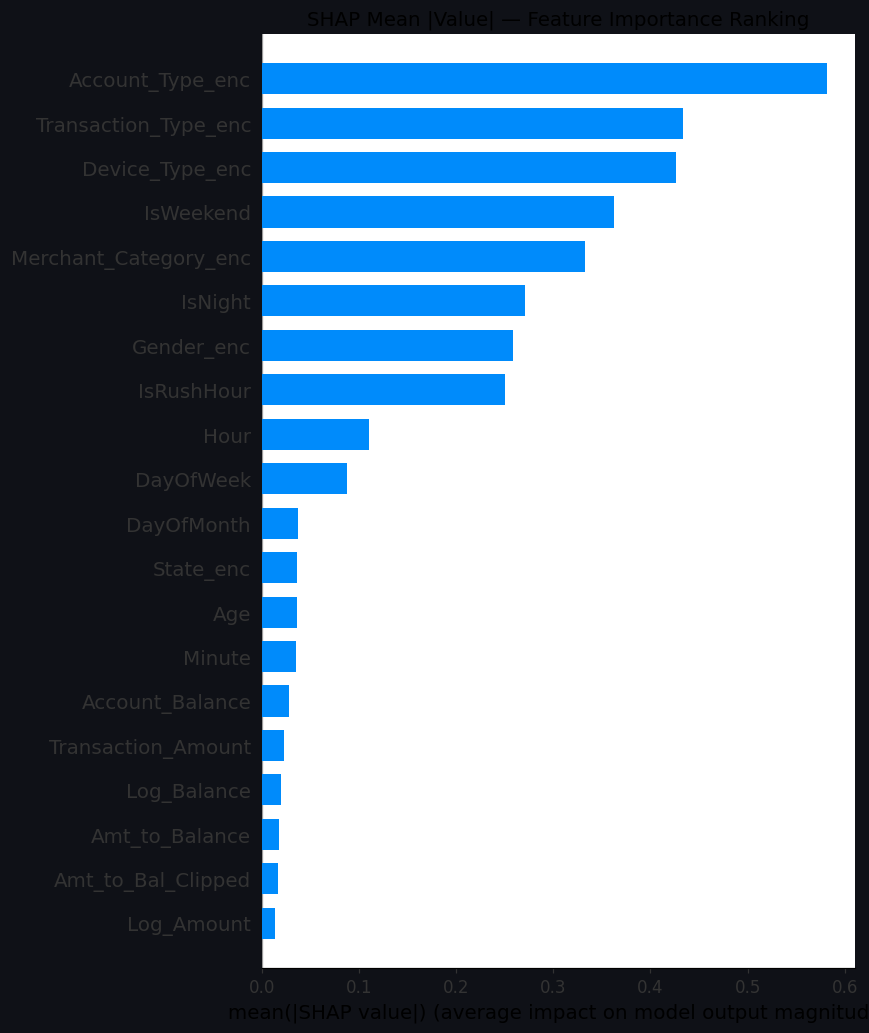

In [8]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_vals, X_shap,
    feature_names=FEATURES,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("SHAP Mean |Value| — Feature Importance Ranking", fontsize=13)
plt.tight_layout()
plt.show()

## Individual Transaction Explanation

Explaining transaction index 272 in SHAP sample
Predicted fraud probability: 0.0822
Actual label: Fraud


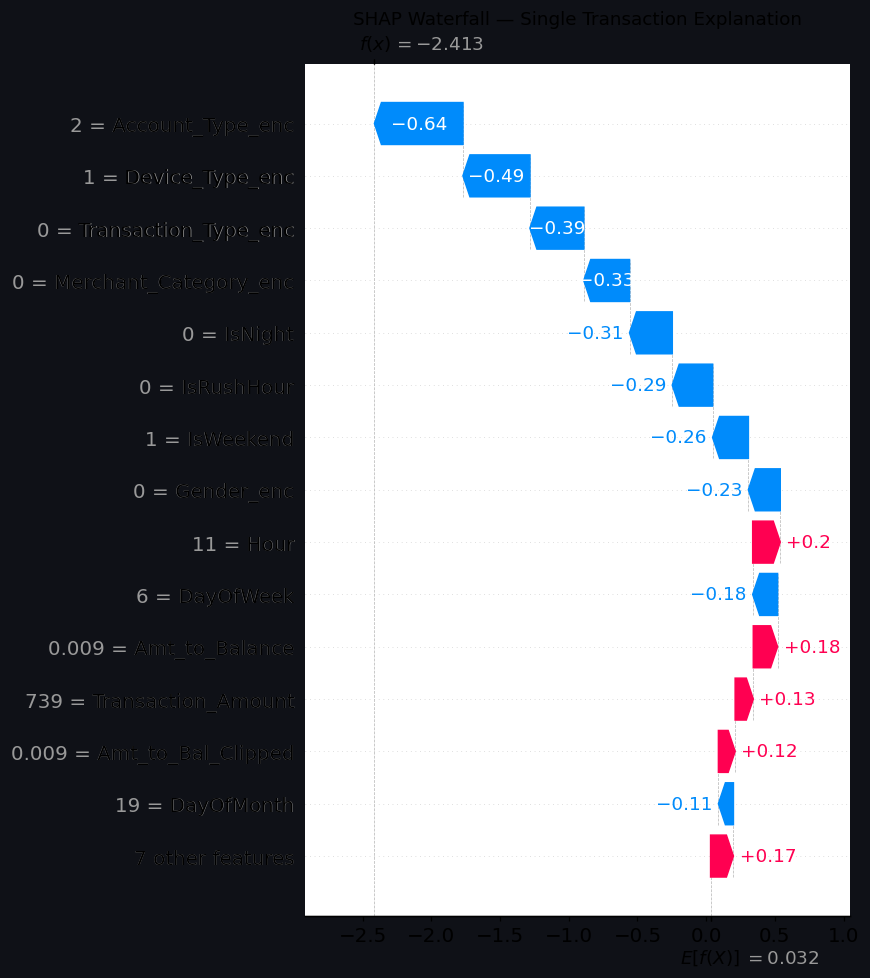

In [9]:
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
fraud_in_sample = np.where(y_test[shap_sample_idx] == 1)[0]

if len(fraud_in_sample) > 0:
    # Find highest probability fraud transaction
    idx = fraud_in_sample[np.argmax(xgb_proba[shap_sample_idx][fraud_in_sample])]
    
    print(f"Explaining transaction index {idx} in SHAP sample")
    print(f"Predicted fraud probability: {xgb_proba[shap_sample_idx][idx]:.4f}")
    print(f"Actual label: {'Fraud' if y_test[shap_sample_idx][idx]==1 else 'Legitimate'}")
    
    # Waterfall plot
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals[idx],
            base_values=explainer.expected_value,
            data=X_shap[idx],
            feature_names=FEATURES,
        ),
        max_display=15,
        show=False
    )
    plt.title("SHAP Waterfall — Single Transaction Explanation", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No fraud transactions in sample - adjust sampling")

## Feature Dependence Plots

<Figure size 1100x660 with 0 Axes>

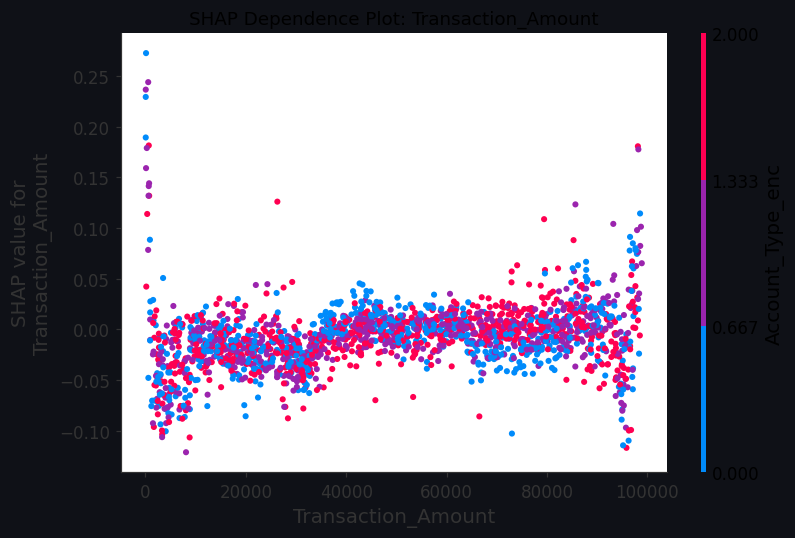

<Figure size 1100x660 with 0 Axes>

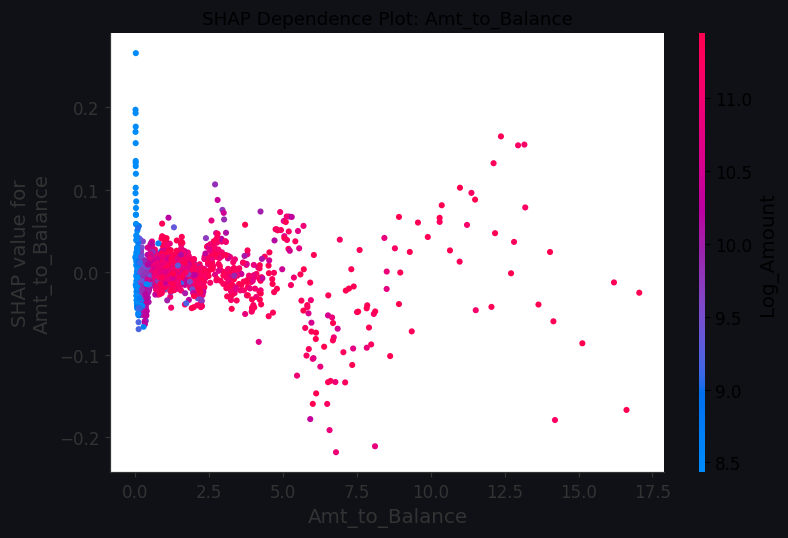

<Figure size 1100x660 with 0 Axes>

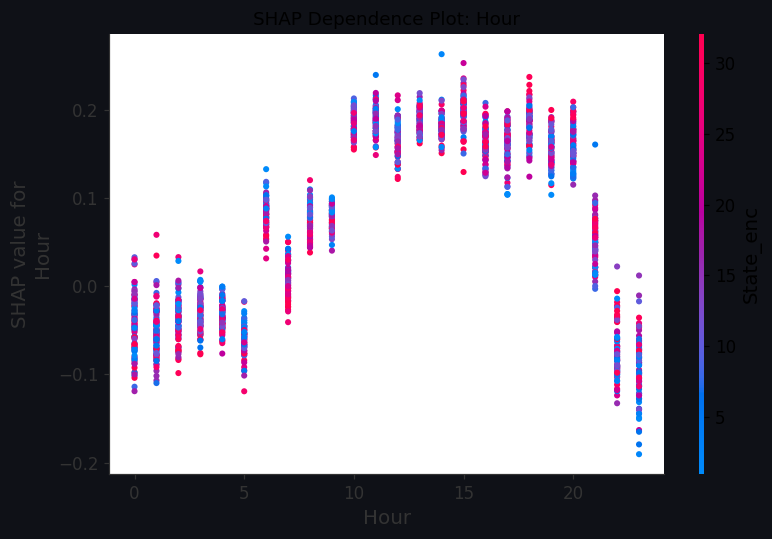

<Figure size 1100x660 with 0 Axes>

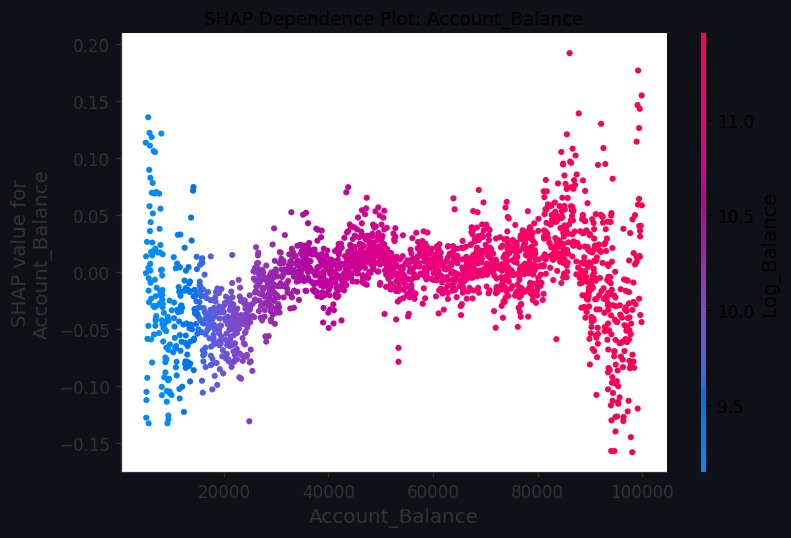

In [10]:
# Most important feature based on SHAP
top_features = ["Transaction_Amount", "Amt_to_Balance", "Hour", "Account_Balance"]

for feature in top_features:
    if feature in FEATURES:
        feature_idx = FEATURES.index(feature)
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(
            feature_idx, shap_vals, X_shap,
            feature_names=FEATURES,
            show=False
        )
        plt.title(f"SHAP Dependence Plot: {feature}", fontsize=12)
        plt.tight_layout()
        plt.show()